In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
# Simple data transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [3]:
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
class LeNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 6*in_channels, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(6*in_channels, 16*in_channels, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16*5*5*in_channels, 120*in_channels),
            nn.Tanh(),
            nn.Linear(120*in_channels, 84*in_channels),
            nn.Tanh(),
            nn.Linear(84*in_channels, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.classifier(x)
        return x

In [5]:
model = LeNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# Training
for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')


Epoch 1, Loss: 1.4624
Epoch 2, Loss: 0.7271
Epoch 3, Loss: 0.6720
Epoch 4, Loss: 0.9479
Epoch 5, Loss: 1.0173
Epoch 6, Loss: 0.6340
Epoch 7, Loss: 0.5628
Epoch 8, Loss: 0.6054
Epoch 9, Loss: 0.1597
Epoch 10, Loss: 0.0770


In [7]:
# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu())
        all_labels.extend(labels.cpu())

# Calculate metrics
acc_LeNet = accuracy_score(all_labels, all_preds)
prec_LeNet= precision_score(all_labels, all_preds, average='macro')
rec_LeNet = recall_score(all_labels, all_preds, average='macro')
f1_LeNet = f1_score(all_labels, all_preds, average='macro')

print(f'\nTest Accuracy: {acc_LeNet:.4f}')
print(f'Precision: {prec_LeNet:.4f}')
print(f'Recall: {rec_LeNet:.4f}')
print(f'F1 Score: {f1_LeNet:.4f}')


Test Accuracy: 0.6696
Precision: 0.6697
Recall: 0.6696
F1 Score: 0.6692


In [8]:
print("Implementing VGG-16")
class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 → 16x16
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 → 8x8
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 → 4x4
            
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 4x4 → 2x2
            
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 2x2 → 1x1
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Implementing VGG-16


In [9]:
model_vgg = VGG16().to(device)
optimizer_vgg = optim.Adam(model_vgg.parameters(), lr=0.001)

In [10]:
print("\nTraining VGG-16...")
for epoch in range(10):
    model_vgg.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_vgg.zero_grad()
        outputs = model_vgg(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_vgg.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')


Training VGG-16...
Epoch 1, Loss: 2.2184
Epoch 2, Loss: 1.5916
Epoch 3, Loss: 1.1746
Epoch 4, Loss: 1.1687
Epoch 5, Loss: 0.8270
Epoch 6, Loss: 0.9965
Epoch 7, Loss: 0.8049
Epoch 8, Loss: 0.6854
Epoch 9, Loss: 0.5596
Epoch 10, Loss: 0.8384


In [11]:
model_vgg.eval()
all_preds_vgg = []
all_labels_vgg = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_vgg(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds_vgg.extend(preds.cpu())
        all_labels_vgg.extend(labels.cpu())

acc_vgg = accuracy_score(all_labels_vgg, all_preds_vgg)
prec_vgg = precision_score(all_labels_vgg, all_preds_vgg, average='macro')
rec_vgg = recall_score(all_labels_vgg, all_preds_vgg, average='macro')
f1_vgg = f1_score(all_labels_vgg, all_preds_vgg, average='macro')

print(f'\nVGG-16 Test Accuracy: {acc_vgg:.4f}')
print(f'VGG-16 Precision: {prec_vgg:.4f}')
print(f'VGG-16 Recall: {rec_vgg:.4f}')
print(f'VGG-16 F1 Score: {f1_vgg:.4f}')


VGG-16 Test Accuracy: 0.6985
VGG-16 Precision: 0.7059
VGG-16 Recall: 0.6985
VGG-16 F1 Score: 0.6933


In [12]:
print("Implementing ResNet-18")
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(identity)
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

Implementing ResNet-18


In [13]:
model_resnet = ResNet18().to(device)
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)

In [14]:
print("Training ResNet-18...")
for epoch in range(10):
    model_resnet.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Training ResNet-18...
Epoch 1, Loss: 1.1621
Epoch 2, Loss: 0.5087
Epoch 3, Loss: 0.4428
Epoch 4, Loss: 0.4244
Epoch 5, Loss: 0.2793
Epoch 6, Loss: 0.9554
Epoch 7, Loss: 0.0663
Epoch 8, Loss: 0.1245
Epoch 9, Loss: 0.1154
Epoch 10, Loss: 0.0251


In [15]:
model_resnet.eval()
all_preds_resnet = []
all_labels_resnet = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds_resnet.extend(preds.cpu())
        all_labels_resnet.extend(labels.cpu())

acc_resnet = accuracy_score(all_labels_resnet, all_preds_resnet)
prec_resnet = precision_score(all_labels_resnet, all_preds_resnet, average='macro')
rec_resnet = recall_score(all_labels_resnet, all_preds_resnet, average='macro')
f1_resnet = f1_score(all_labels_resnet, all_preds_resnet, average='macro')

print(f'\nResNet-18 Test Accuracy: {acc_resnet:.4f}')
print(f'ResNet-18 Precision: {prec_resnet:.4f}')
print(f'ResNet-18 Recall: {rec_resnet:.4f}')
print(f'ResNet-18 F1 Score: {f1_resnet:.4f}')


ResNet-18 Test Accuracy: 0.8346
ResNet-18 Precision: 0.8389
ResNet-18 Recall: 0.8346
ResNet-18 F1 Score: 0.8346


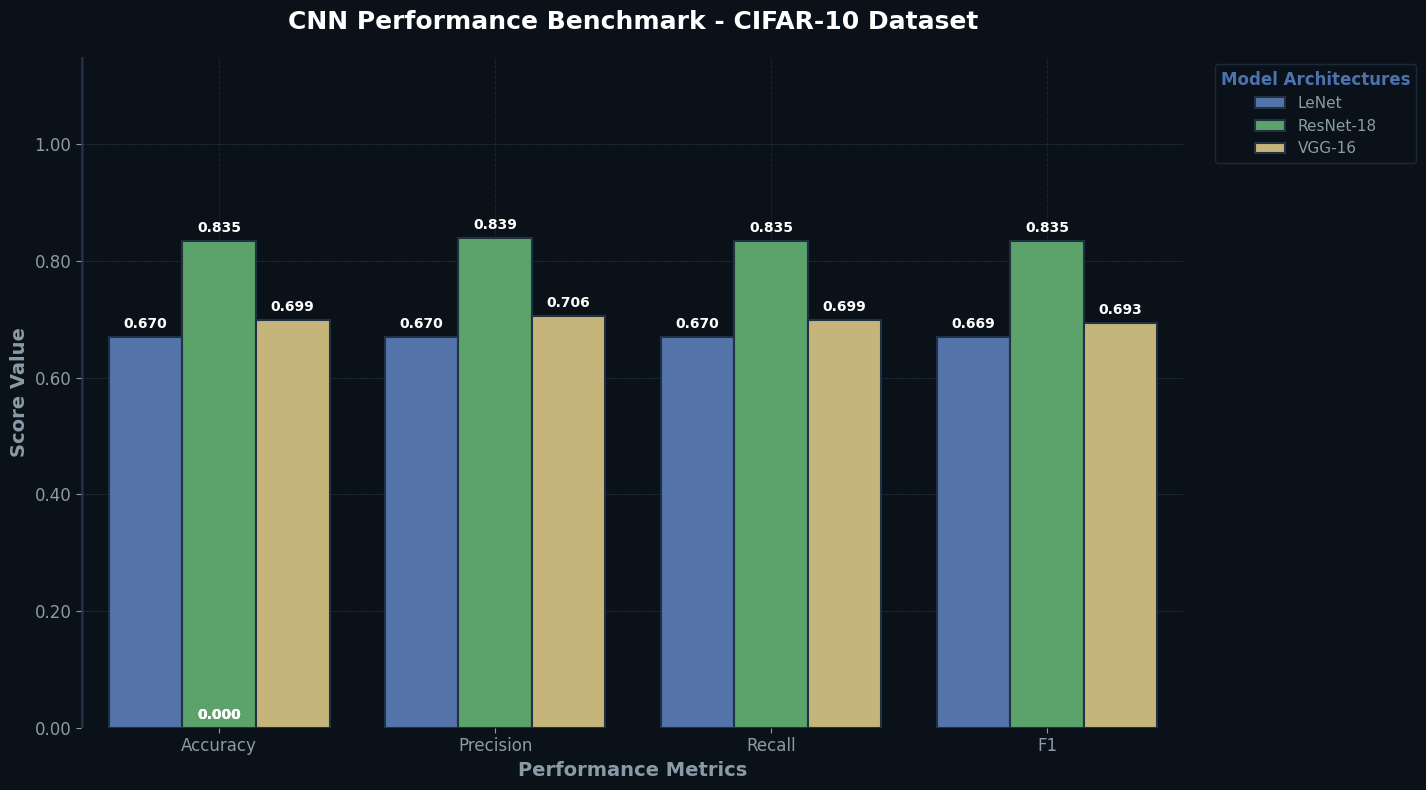

In [ ]:
etrics = {
    'LeNet': {'Accuracy': acc_LeNet, 'Precision': prec_LeNet, 'Recall': rec_LeNet, 'F1': f1_LeNet},
    'ResNet-18': {'Accuracy': acc_resnet, 'Precision': prec_resnet, 'Recall': rec_resnet, 'F1': f1_resnet},
    'VGG-16': {'Accuracy': acc_vgg, 'Precision': prec_vgg, 'Recall': rec_vgg, 'F1': f1_vgg}
}

# Convert to DataFrame for easier plotting
import pandas as pd
df = pd.DataFrame(metrics).T
df = df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
df.rename(columns={'index': 'Model'}, inplace=True)

# Modern Dark Blue Theme
plt.style.use('dark_background')
custom_palette = ["#4C72B0", "#55A868", "#CCB974"]  # Blue-dominated palette
sns.set_palette(custom_palette)

# Create figure with dark background
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0b1118')
fig.set_facecolor('#0b1118')

# Create grouped bar plot with modern styling
bar_plot = sns.barplot(data=df, x='Metric', y='Score', hue='Model', ax=ax,
                       saturation=0.85, edgecolor='#203144', linewidth=1.5)

# Add value labels with modern typography
for patch in bar_plot.patches:
    height = patch.get_height()
    ax.text(x=patch.get_x() + patch.get_width()/2, 
            y=height + 0.01,
            s=f'{height:.3f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color='white',
            fontfamily='sans-serif')

# Title and labels styling
ax.set_title('CNN Performance Benchmark - CIFAR-10 Dataset',
             fontsize=18, fontweight='bold', color='white', pad=20,
             fontfamily='sans-serif',
             loc='center')  # Left-aligned title

ax.set_xlabel('Performance Metrics', 
              fontsize=14, fontweight='semibold', color='#8A9BA8',
              fontfamily='sans-serif')
ax.set_ylabel('Score Value', 
              fontsize=14, fontweight='semibold', color='#8A9BA8',
              fontfamily='sans-serif')

# Custom grid lines
ax.grid(True, color='#203144', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

# Custom ticks and spine removal
ax.tick_params(axis='both', colors='#8A9BA8', labelsize=12)
sns.despine(left=True, bottom=True)

# Legend styling with modern aesthetics
legend = ax.legend(title='Model Architectures',
                  title_fontsize=12,
                  fontsize=11,
                  facecolor='#0b1118',
                  edgecolor='#203144',
                  bbox_to_anchor=(1.02, 1),
                  loc='upper left',
                  labelcolor='#8A9BA8')
legend.get_title().set_color('#4C72B0')
legend.get_title().set_fontweight('bold')

# Custom y-axis formatting
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

# Add subtle gradient background
ax.set_facecolor('#0b1118')

# Add modern horizontal lines
for y in np.arange(0.2, 1.21, 0.2):
    ax.axhline(y=y, color='#203144', linewidth=0.7, zorder=0, alpha=0.4)

# Add modern color accents
ax.axvline(x=-0.5, color='#4C72B0', linewidth=4, alpha=0.3, ymin=0, ymax=1)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make space for legend
plt.show()